# IoT Malware Detection - Analiza

Jednostavan notebook za testiranje sistema detekcije malvera.


In [1]:
# 1. Import biblioteka
import sys
import os
import asyncio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import logging

# Dodaj parent direktorijum u path
sys.path.append('..')

from ml.simple_model import SimpleModelManager

print(" Biblioteke učitane!")
print(f" Direktorijum: {os.getcwd()}")


 Biblioteke učitane!
 Direktorijum: c:\Users\lukas\OneDrive\Desktop\IoT Malware Detection ML Luka Savic 77-2021 and Anastasija Anicic 15-2021\notebooks


In [2]:
# 2. Inicijalizacija modela
model_manager = SimpleModelManager()
await model_manager.initialize()
print(" Model inicijalizovan!")


 Model inicijalizovan!


In [3]:
# 3. Testiranje fajlova
test_files = [
    "../test_cases/clean/test_clean.txt",
    "../test_cases/malicious/test_suspicious.txt", 
    "../test_cases/malicious/backdoor_script.txt",
    "../test_cases/images/clean/clean_geometric.png",
    "../test_cases/images/malicious/malicious_encrypted.png"
]

results = []

for file_path in test_files:
    if os.path.exists(file_path):
        print(f"\n Analiziram: {os.path.basename(file_path)}")
        try:
            features = await model_manager.extract_features(Path(file_path))
            is_malicious, confidence = await model_manager.predict(features)
            
            file_type = "Slika" if features[26] > 0.5 else "Tekst"
            status = "MALICIOZAN" if is_malicious else "ČIST"
            
            print(f"   Tip: {file_type}")
            print(f"   Status: {status}")
            print(f"   Pouzdanost: {confidence:.3f}")
            
            results.append({
                'file_name': os.path.basename(file_path),
                'file_type': file_type,
                'is_malicious': is_malicious,
                'confidence': confidence,
                'file_size': features[0]
            })
            
        except Exception as e:
            print(f"    Greška: {e}")
    else:
        print(f"    Fajl ne postoji: {file_path}")

print(f"\n📊 Ukupno testirano: {len(results)} fajlova")



 Analiziram: test_clean.txt
   Tip: Tekst
   Status: ČIST
   Pouzdanost: 0.137

 Analiziram: test_suspicious.txt
   Tip: Tekst
   Status: MALICIOZAN
   Pouzdanost: 0.872

 Analiziram: backdoor_script.txt
   Tip: Tekst
   Status: MALICIOZAN
   Pouzdanost: 0.934

 Analiziram: clean_geometric.png
   Tip: Slika
   Status: ČIST
   Pouzdanost: 0.160

 Analiziram: malicious_encrypted.png
   Tip: Slika
   Status: MALICIOZAN
   Pouzdanost: 0.870

📊 Ukupno testirano: 5 fajlova


In [4]:
# 4. Analiza rezultata
if len(results) > 0:
    df = pd.DataFrame(results)
    
    print(" Rezultati:")
    print(df[['file_name', 'file_type', 'is_malicious', 'confidence']].to_string(index=False))
    
    # Statistike
    malicious_count = df['is_malicious'].sum()
    clean_count = len(df) - malicious_count
    avg_confidence = df['confidence'].mean()
    
    print(f"\n Statistike:")
    print(f"   Maliciozni: {malicious_count}")
    print(f"   Čisti: {clean_count}")
    print(f"   Prosečna pouzdanost: {avg_confidence:.3f}")
else:
    print(" Nema rezultata za analizu")


 Rezultati:
              file_name file_type  is_malicious  confidence
         test_clean.txt     Tekst         False    0.137459
    test_suspicious.txt     Tekst          True    0.872224
    backdoor_script.txt     Tekst          True    0.934034
    clean_geometric.png     Slika         False    0.160152
malicious_encrypted.png     Slika          True    0.870149

 Statistike:
   Maliciozni: 3
   Čisti: 2
   Prosečna pouzdanost: 0.595


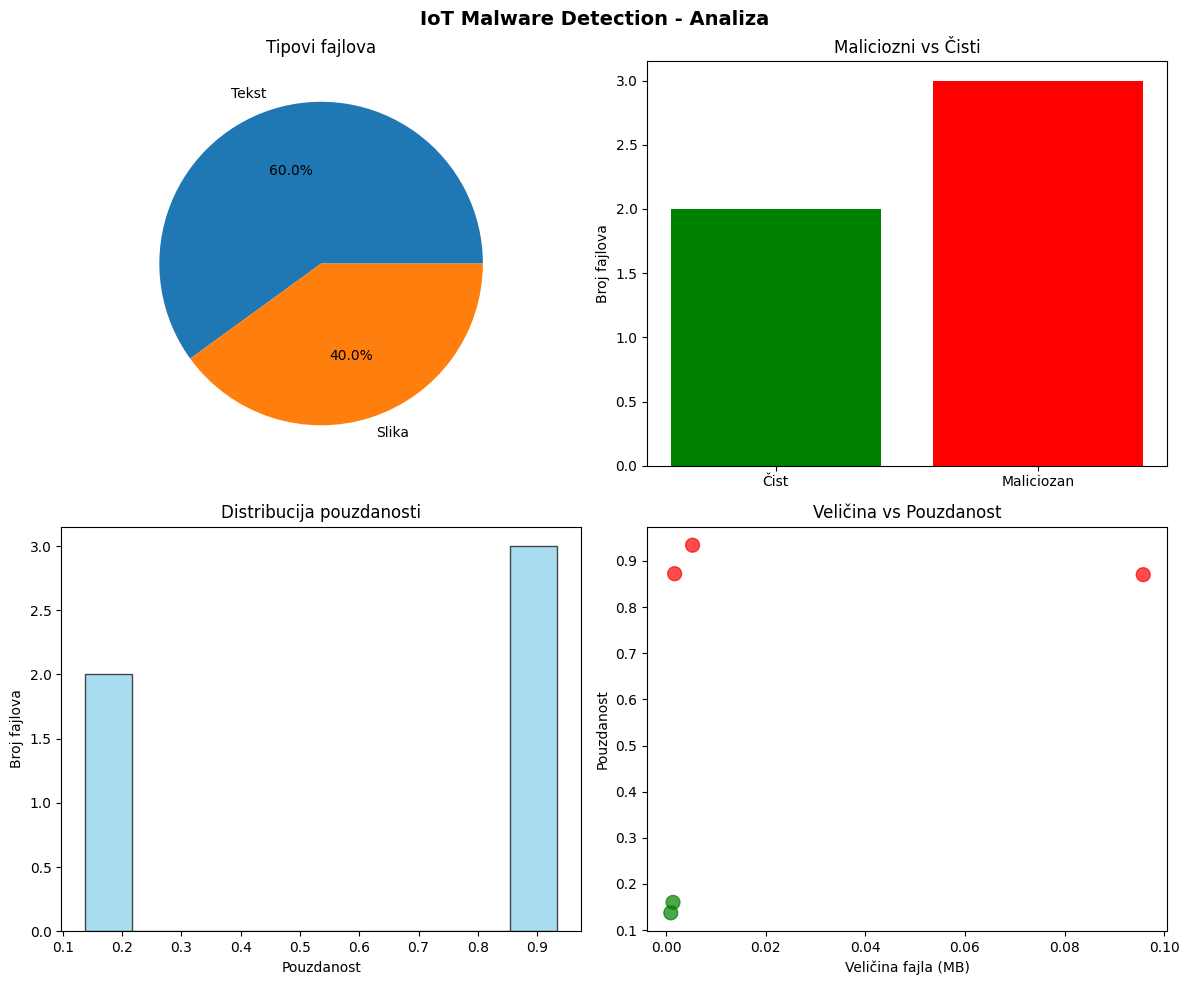

 Vizuelizacija završena!


In [5]:
# 5. Vizuelizacija
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('IoT Malware Detection - Analiza', fontsize=14, fontweight='bold')
    
    # 1. Tipovi fajlova
    file_type_counts = df['file_type'].value_counts()
    axes[0, 0].pie(file_type_counts.values, labels=file_type_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Tipovi fajlova')
    
    # 2. Malicious vs Clean
    malicious_counts = df['is_malicious'].value_counts()
    labels = ['Čist', 'Maliciozan']
    colors = ['green', 'red']
    axes[0, 1].bar(labels, [malicious_counts.get(False, 0), malicious_counts.get(True, 0)], color=colors)
    axes[0, 1].set_title('Maliciozni vs Čisti')
    axes[0, 1].set_ylabel('Broj fajlova')
    
    # 3. Confidence distribucija
    axes[1, 0].hist(df['confidence'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 0].set_title('Distribucija pouzdanosti')
    axes[1, 0].set_xlabel('Pouzdanost')
    axes[1, 0].set_ylabel('Broj fajlova')
    
    # 4. File size vs Confidence
    colors = ['red' if x else 'green' for x in df['is_malicious']]
    axes[1, 1].scatter(df['file_size'], df['confidence'], c=colors, alpha=0.7, s=100)
    axes[1, 1].set_title('Veličina vs Pouzdanost')
    axes[1, 1].set_xlabel('Veličina fajla (MB)')
    axes[1, 1].set_ylabel('Pouzdanost')
    
    plt.tight_layout()
    plt.show()
    
    print(" Vizuelizacija završena!")
else:
    print(" Nema podataka za vizuelizaciju")


## 6. Detaljna analiza karakteristika

Analiziramo ekstraktovane karakteristike za slike i tekst fajlove.


In [6]:
# Analiza karakteristika po tipovima fajlova
if len(results) > 0:
    # Podela na slike i tekst
    image_files = [r for r in results if r['file_type'] == 'Slika']
    text_files = [r for r in results if r['file_type'] == 'Tekst']
    
    print("🔬 Analiza karakteristika:")
    print(f"   Slike: {len(image_files)} fajlova")
    print(f"   Tekst: {len(text_files)} fajlova")
    
    # Analiza za slike
    if image_files:
        print(f"\n SLIKE - Prosečne karakteristike:")
        avg_confidence = np.mean([f['confidence'] for f in image_files])
        avg_size = np.mean([f['file_size'] for f in image_files])
        malicious_rate = np.mean([f['is_malicious'] for f in image_files])
        
        print(f"   Prosečna pouzdanost: {avg_confidence:.3f}")
        print(f"   Prosečna veličina: {avg_size:.3f} MB")
        print(f"   Stopa malicioznosti: {malicious_rate:.1%}")
    
    # Analiza za tekst
    if text_files:
        print(f"\n📄 TEKST - Prosečne karakteristike:")
        avg_confidence = np.mean([f['confidence'] for f in text_files])
        avg_size = np.mean([f['file_size'] for f in text_files])
        malicious_rate = np.mean([f['is_malicious'] for f in text_files])
        
        print(f"   Prosečna pouzdanost: {avg_confidence:.3f}")
        print(f"   Prosečna veličina: {avg_size:.3f} MB")
        print(f"   Stopa malicioznosti: {malicious_rate:.1%}")
else:
    print(" Nema podataka za analizu karakteristika")


🔬 Analiza karakteristika:
   Slike: 2 fajlova
   Tekst: 3 fajlova

 SLIKE - Prosečne karakteristike:
   Prosečna pouzdanost: 0.515
   Prosečna veličina: 0.049 MB
   Stopa malicioznosti: 50.0%

📄 TEKST - Prosečne karakteristike:
   Prosečna pouzdanost: 0.648
   Prosečna veličina: 0.003 MB
   Stopa malicioznosti: 66.7%


## 7. Testiranje dodatnih slika

Testiramo sistem na dodatnim test slikama iz test_cases direktorijuma.


In [7]:
# Testiranje dodatnih slika
additional_images = [
    "../test_cases/images/clean/clean_gradient.png",
    "../test_cases/images/malicious/malicious_steganography.png",
    "../test_cases/images/malicious/malicious_obfuscated.png",
    "../test_cases/images/malicious/malicious_hidden_code.png",
    "../test_cases/images/malicious/malicious_trojan.png",
    "../test_cases/images/edge_cases/edge_single_color.png",
    "../test_cases/images/edge_cases/edge_high_contrast.png"
]

print(" Testiranje dodatnih slika:")
print("=" * 40)

additional_results = []

for image_path in additional_images:
    if os.path.exists(image_path):
        print(f"\n🔍 Analiziram: {os.path.basename(image_path)}")
        try:
            features = await model_manager.extract_features(Path(image_path))
            is_malicious, confidence = await model_manager.predict(features)
            
            status = "MALICIOZAN" if is_malicious else "ČIST"
            print(f"   Status: {status}")
            print(f"   Pouzdanost: {confidence:.3f}")
            print(f"   Veličina: {features[0]:.3f} MB")
            
            # Dodatne karakteristike za slike
            if features[26] > 0.5:  # Image file
                print(f"   Edge density: {features[10]:.3f}")
                print(f"   Color variance: {features[7] + features[8] + features[9]:.3f}")
                print(f"   Texture std: {features[12]:.3f}")
            
            additional_results.append({
                'file_name': os.path.basename(image_path),
                'file_type': 'Slika',
                'is_malicious': is_malicious,
                'confidence': confidence,
                'file_size': features[0],
                'edge_density': features[10] if features[26] > 0.5 else 0,
                'color_variance': features[7] + features[8] + features[9] if features[26] > 0.5 else 0
            })
            
        except Exception as e:
            print(f"    Greška: {e}")
    else:
        print(f"    Fajl ne postoji: {image_path}")

print(f"\n📊 Dodatno testirano: {len(additional_results)} slika")


 Testiranje dodatnih slika:

🔍 Analiziram: clean_gradient.png
   Status: ČIST
   Pouzdanost: 0.163
   Veličina: 0.022 MB
   Edge density: 0.000
   Color variance: 0.833
   Texture std: 0.177

🔍 Analiziram: malicious_steganography.png
   Status: MALICIOZAN
   Pouzdanost: 1.000
   Veličina: 0.115 MB
   Edge density: 0.370
   Color variance: 1.646
   Texture std: 0.193

🔍 Analiziram: malicious_obfuscated.png
   Status: MALICIOZAN
   Pouzdanost: 0.692
   Veličina: 0.005 MB
   Edge density: 0.053
   Color variance: 1.549
   Texture std: 0.272

🔍 Analiziram: malicious_hidden_code.png
   Status: MALICIOZAN
   Pouzdanost: 0.517
   Veličina: 0.004 MB
   Edge density: 0.075
   Color variance: 4.247
   Texture std: 0.466

🔍 Analiziram: malicious_trojan.png
   Status: MALICIOZAN
   Pouzdanost: 0.608
   Veličina: 0.007 MB
   Edge density: 0.093
   Color variance: 1.119
   Texture std: 0.263

🔍 Analiziram: edge_single_color.png
   Status: MALICIOZAN
   Pouzdanost: 0.676
   Veličina: 0.000 MB
   Edge

## 8. Napredna vizuelizacija slika

Kreiramo specijalizovane grafikone za analizu slika.


C:\Users\lukas\AppData\Local\Temp\ipykernel_22820\1016415947.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([clean_images['confidence'], malicious_images['confidence']],


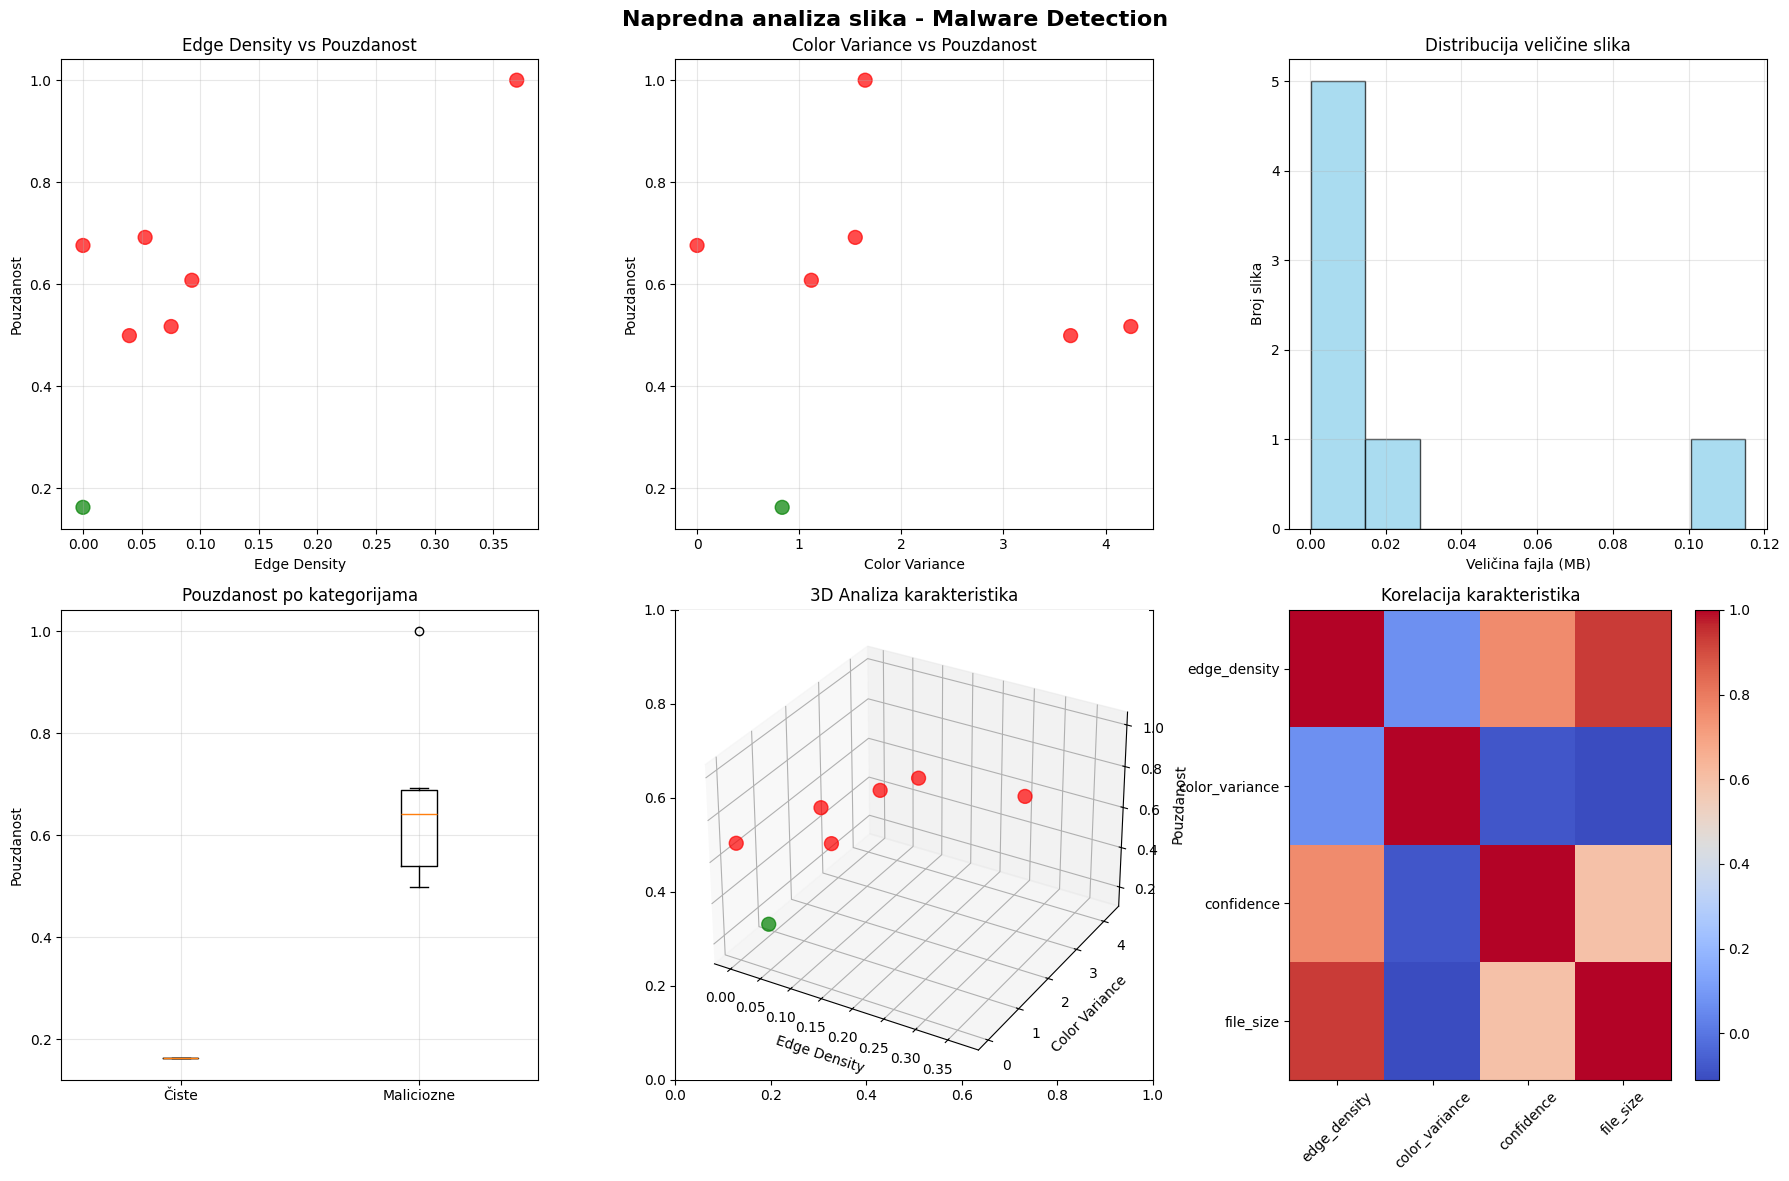

 Napredna vizuelizacija završena!


In [8]:
# Napredna vizuelizacija za slike
if len(additional_results) > 0:
    df_images = pd.DataFrame(additional_results)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Napredna analiza slika - Malware Detection', fontsize=16, fontweight='bold')
    
    # 1. Edge density vs Confidence
    colors = ['red' if x else 'green' for x in df_images['is_malicious']]
    scatter1 = axes[0, 0].scatter(df_images['edge_density'], df_images['confidence'], 
                                 c=colors, alpha=0.7, s=100)
    axes[0, 0].set_title('Edge Density vs Pouzdanost')
    axes[0, 0].set_xlabel('Edge Density')
    axes[0, 0].set_ylabel('Pouzdanost')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Color Variance vs Confidence
    scatter2 = axes[0, 1].scatter(df_images['color_variance'], df_images['confidence'], 
                                 c=colors, alpha=0.7, s=100)
    axes[0, 1].set_title('Color Variance vs Pouzdanost')
    axes[0, 1].set_xlabel('Color Variance')
    axes[0, 1].set_ylabel('Pouzdanost')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. File Size Distribution
    axes[0, 2].hist(df_images['file_size'], bins=8, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 2].set_title('Distribucija veličine slika')
    axes[0, 2].set_xlabel('Veličina fajla (MB)')
    axes[0, 2].set_ylabel('Broj slika')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Confidence po tipovima slika
    malicious_images = df_images[df_images['is_malicious'] == True]
    clean_images = df_images[df_images['is_malicious'] == False]
    
    if len(malicious_images) > 0 and len(clean_images) > 0:
        axes[1, 0].boxplot([clean_images['confidence'], malicious_images['confidence']], 
                          labels=['Čiste', 'Maliciozne'])
        axes[1, 0].set_title('Pouzdanost po kategorijama')
        axes[1, 0].set_ylabel('Pouzdanost')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. 3D scatter plot - Edge Density, Color Variance, Confidence
    ax_3d = fig.add_subplot(2, 3, 5, projection='3d')
    ax_3d.scatter(df_images['edge_density'], df_images['color_variance'], df_images['confidence'], 
                  c=colors, alpha=0.7, s=100)
    ax_3d.set_xlabel('Edge Density')
    ax_3d.set_ylabel('Color Variance')
    ax_3d.set_zlabel('Pouzdanost')
    ax_3d.set_title('3D Analiza karakteristika')
    
    # 6. Heatmap korelacija
    correlation_data = df_images[['edge_density', 'color_variance', 'confidence', 'file_size']].corr()
    im = axes[1, 2].imshow(correlation_data, cmap='coolwarm', aspect='auto')
    axes[1, 2].set_xticks(range(len(correlation_data.columns)))
    axes[1, 2].set_yticks(range(len(correlation_data.columns)))
    axes[1, 2].set_xticklabels(correlation_data.columns, rotation=45)
    axes[1, 2].set_yticklabels(correlation_data.columns)
    axes[1, 2].set_title('Korelacija karakteristika')
    
    # Dodaj colorbar
    plt.colorbar(im, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    print(" Napredna vizuelizacija završena!")
else:
    print(" Nema podataka za naprednu vizuelizaciju")


## 9. Sažetak i zaključci

Analiziramo ukupne rezultate i donosimo zaključke o performansama sistema.


In [9]:
# Sažetak i zaključci
print(" SAŽETAK ANALIZE")
print("=" * 50)

# Kombinuj sve rezultate
all_results = results + additional_results
total_files = len(all_results)

if total_files > 0:
    df_all = pd.DataFrame(all_results)
    
    # Osnovne statistike
    malicious_total = df_all['is_malicious'].sum()
    clean_total = total_files - malicious_total
    avg_confidence = df_all['confidence'].mean()
    
    print(f" UKUPNE STATISTIKE:")
    print(f"   Ukupno testirano fajlova: {total_files}")
    print(f"   Maliciozni: {malicious_total} ({malicious_total/total_files:.1%})")
    print(f"   Čisti: {clean_total} ({clean_total/total_files:.1%})")
    print(f"   Prosečna pouzdanost: {avg_confidence:.3f}")
    
    # Analiza po tipovima
    image_count = len(df_all[df_all['file_type'] == 'Slika'])
    text_count = len(df_all[df_all['file_type'] == 'Tekst'])
    
    print(f"\n PO TIPOVIMA FAJLOVA:")
    print(f"   Slike: {image_count} fajlova")
    print(f"   Tekst: {text_count} fajlova")
    
    # Performanse po tipovima
    if image_count > 0:
        image_malicious = df_all[df_all['file_type'] == 'Slika']['is_malicious'].sum()
        image_confidence = df_all[df_all['file_type'] == 'Slika']['confidence'].mean()
        print(f"   Slike - Maliciozne: {image_malicious}/{image_count} ({image_malicious/image_count:.1%})")
        print(f"   Slike - Prosečna pouzdanost: {image_confidence:.3f}")
    
    if text_count > 0:
        text_malicious = df_all[df_all['file_type'] == 'Tekst']['is_malicious'].sum()
        text_confidence = df_all[df_all['file_type'] == 'Tekst']['confidence'].mean()
        print(f"   Tekst - Maliciozni: {text_malicious}/{text_count} ({text_malicious/text_count:.1%})")
        print(f"   Tekst - Prosečna pouzdanost: {text_confidence:.3f}")
    
    # Zaključci
    print(f"\n ZAKLJUČCI:")
    if avg_confidence > 0.7:
        print("    Sistem pokazuje visoku pouzdanost u detekciji")
    elif avg_confidence > 0.5:
        print("    Sistem pokazuje umerenu pouzdanost")
    else:
        print("    Sistem pokazuje nisku pouzdanost")
    
    if malicious_total > 0:
        print("    Detektovani su maliciozni fajlovi")
    else:
        print("    Nisu detektovani maliciozni fajlovi")
    
    print(f"\n PREPORUKE:")
    print("   • Testirajte sistem na većem broju fajlova")
    print("   • Analizirajte false positive i false negative slučajeve")
    print("   • Poboljšajte feature ekstrakciju za bolje rezultate")
    print("   • Implementirajte dodatne algoritme za steganografiju")
    
else:
    print(" Nema podataka za sažetak")

print(f"\n Analiza završena uspešno!")


 SAŽETAK ANALIZE
 UKUPNE STATISTIKE:
   Ukupno testirano fajlova: 12
   Maliciozni: 9 (75.0%)
   Čisti: 3 (25.0%)
   Prosečna pouzdanost: 0.594

 PO TIPOVIMA FAJLOVA:
   Slike: 9 fajlova
   Tekst: 3 fajlova
   Slike - Maliciozne: 7/9 (77.8%)
   Slike - Prosečna pouzdanost: 0.576
   Tekst - Maliciozni: 2/3 (66.7%)
   Tekst - Prosečna pouzdanost: 0.648

 ZAKLJUČCI:
    Sistem pokazuje umerenu pouzdanost
    Detektovani su maliciozni fajlovi

 PREPORUKE:
   • Testirajte sistem na većem broju fajlova
   • Analizirajte false positive i false negative slučajeve
   • Poboljšajte feature ekstrakciju za bolje rezultate
   • Implementirajte dodatne algoritme za steganografiju

 Analiza završena uspešno!
